In [11]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [ ]:
df= pd.read_csv('./data/_data.csv')
print("Первичный осмотр данных")


Первичный осмотр данных


<StringArray>
[                            nan,         'Индивидуальный проект',
         'индивидуальный проект',           '1МГ-601 (1МГ-601-Ж)',
                           'ЛСР',                         'II-57',
                      'II-68-01',                      'I-515/9М',
                          'СМ-6',           'II-29-3(II-29-3(9))',
 ...
                      'Хрущевка',                           '504',
                       'И-155Б2',                      'I-515/9M',
 'I-447 (модификация I-447С-39)',                         'I-447',
                          '1973',                'И-209А (И-209)',
                      'II-18-12',                        'П 44-Т']
Length: 394, dtype: str

In [ ]:
#ПРоцент пустых значений для столбцов
df.isna().mean()

Unnamed: 0                  0.000000
ID  объявления              0.000000
Количество комнат           0.044548
Тип                         0.000000
Метро                       0.056274
Адрес                       0.000000
Площадь, м2                 0.000000
Дом                         0.000000
Парковка                    0.574161
Цена                        0.000000
Телефоны                    0.000000
Описание                    0.000000
Ремонт                      0.117896
Площадь комнат, м2          0.381291
Балкон                      0.341407
Окна                        0.282994
Санузел                     0.114344
Можно с детьми/животными    0.260870
Дополнительно               0.015277
Название ЖК                 0.749743
Серия дома                  0.907438
Высота потолков, м          0.520455
Лифт                        0.235365
Мусоропровод                0.450274
Ссылка на объявление        0.000000
dtype: float64

In [13]:
#выделение города из адреса
df[['Город', 'Адрес']]=df['Адрес'].str.split(',', n=1, expand=True)
df['Город']=df['Город'].str.strip()
df['Адрес']=df['Адрес'].str.strip()


In [14]:
# сохранение результата без СПб и Краснодара
df=df[~((df['Город']=='Санкт-Петербург') | (df['Город']=='Краснодарский край'))]


In [ ]:
# Выделение столбцов этаж квартиры, этажность дома, тип дома
df[['этажи', 'тип_дома']] = df['Дом'].str.split(',', n=1, expand=True)
df[['этаж_квартиры', 'этажность_дома']] = df['этажи'].str.split('/', n=1, expand=True)

df['этаж_квартиры'] = df['этаж_квартиры'].str.strip()
df['этажность_дома'] = df['этажность_дома'].str.strip()
df['тип_дома'] = df['тип_дома'].str.strip()

df = df.drop('этажи', axis=1)

In [ ]:
#Приведение лифтов к бинарному значению
df['Лифт'] = df['Лифт'].fillna(0)
df['Лифт'] = df['Лифт'].astype(bool).astype(int)

In [ ]:
#Приведение паркинга к бинарному значению
df['Парковка'] = df['Парковка'].fillna(0)
df['Парковка'] = df['Парковка'].astype(bool).astype(int)

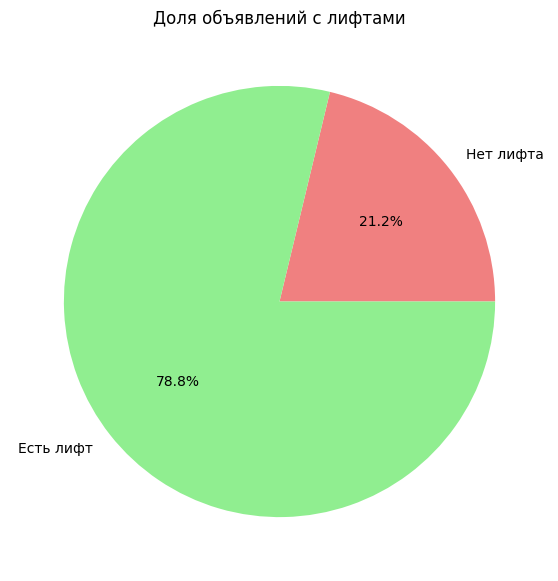

In [ ]:
#График наличие лифта
counts = df['Лифт'].value_counts().sort_index()
counts.index = ['Нет лифта', 'Есть лифт']

plt.figure(figsize=(7, 7))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('Доля объявлений с лифтами')
plt.show()

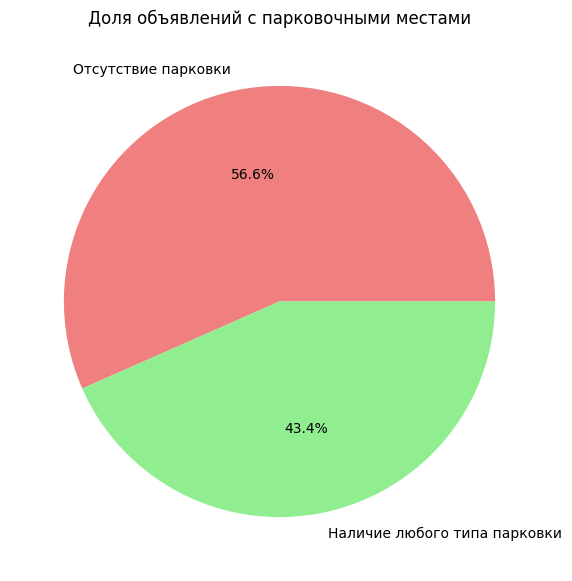

In [ ]:
#График наличие парковки
counts = df['Парковка'].value_counts().sort_index()
counts.index = ['Отсутствие парковки', 'Наличие любого типа парковки']

plt.figure(figsize=(7, 7))
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightgreen'])
plt.title('Доля объявлений с парковочными местами')
plt.show()